# Illumicell AI — Blood Cell Classifier (Option A)

**2026 Venture & Tech Summer Program · Technical Track**

This notebook teaches a computer-vision model to look at a microscope image of a white blood cell and identify its type. It uses the public **Kaggle Blood Cell Images** dataset (~12,500 labeled images, 4 cell types). No real patient data is used.

It is organized in the same order your weekly guidelines ask for:

1. **Setup** — turn on the GPU, import libraries (Week 2, Day 1)
2. **Load** — read the full dataset, confirm categories and counts (Week 2, Day 1)
3. **Explore** — show labeled examples, check class balance (Week 2, Day 2)
4. **Prepare** — resize + normalize images, encode labels, save the mapping (Week 2, Day 3)
5. **Split** — a fair, reproducible train/test split (Week 2, Day 4)
6. **Train** — transfer learning on a pre-trained model (Week 3, Day 1)
7. **Evaluate** — accuracy + confusion matrix (Week 3, Days 2-3)
8. **Study failures** — look at wrong predictions (Week 3, Day 4)
9. **Improve** — data augmentation, re-measure (Week 4, Day 1)
10. **Save** — export the model + label map for the Streamlit app (Week 4)

> **How to run:** `Runtime → Change runtime type → GPU`, then `Runtime → Run all`. Do the one-time dataset step in Section 1 first.

## 1. Setup — GPU + libraries

Enable the GPU first: **Runtime → Change runtime type → Hardware accelerator → GPU**. Then run this cell. It should print a GPU device; if it prints an empty list, the GPU is not on and training will be very slow.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import json, os, pathlib
tf.keras.utils.set_random_seed(42)

print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPUs visible to TensorFlow:', gpus)
if not gpus:
    print('WARNING: No GPU detected. Go to Runtime > Change runtime type > GPU, then Run all again.')
else:
    print('GPU is ready. Training will be fast.')

TensorFlow version: 2.20.0
GPUs visible to TensorFlow: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is ready. Training will be fast.


### 1a. Get the dataset (one-time step)

The Kaggle dataset is `paultimothymooney/blood-cells`. Pick **one** of the two options below.

**Option 1 — Kaggle API (recommended).** In Kaggle: *Account → Settings → Create New Token*. This downloads `kaggle.json`. Upload it when the cell asks, and the dataset downloads automatically.

**Option 2 — manual upload.** Download the dataset zip from the Kaggle page yourself, then use the Colab file panel (folder icon on the left) to upload it, and unzip it with `!unzip yourfile.zip`.

Either way, you want a folder that contains `dataset2-master/images/TRAIN` with four subfolders (EOSINOPHIL, LYMPHOCYTE, MONOCYTE, NEUTROPHIL).

In [2]:
# --- Option 1: Kaggle API ---
# Run this cell, click 'Choose Files', and select your kaggle.json.
from google.colab import files
import os

if not os.path.exists('/root/.kaggle/kaggle.json'):
    print('Upload your kaggle.json (from Kaggle > Account > Create New Token):')
    uploaded = files.upload()  # choose kaggle.json
    os.makedirs('/root/.kaggle', exist_ok=True)
    !cp kaggle.json /root/.kaggle/kaggle.json
    !chmod 600 /root/.kaggle/kaggle.json

!pip -q install kaggle
!kaggle datasets download -d paultimothymooney/blood-cells -p /content --unzip
print('Done. Contents of /content:')
!ls /content

Upload your kaggle.json (from Kaggle > Account > Create New Token):


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/blood-cells
License(s): other
100% 108M/108M [00:00<00:00, 126MB/s] 

Done. Contents of /content:
dataset2-master  dataset-master  kaggle.json  sample_data


In [3]:
# Find the dataset's provided TRAIN and TEST folders.
possible_roots = [
    '/content/dataset2-master/dataset2-master/images',
    '/content/dataset2-master/images',
]
DATA_ROOT = next((p for p in possible_roots if os.path.isdir(p)), None)
assert DATA_ROOT is not None, 'Dataset folder not found. Check the unzip output above.'
TRAIN_DIR = os.path.join(DATA_ROOT, 'TRAIN')
TEST_DIR = os.path.join(DATA_ROOT, 'TEST')
assert os.path.isdir(TRAIN_DIR) and os.path.isdir(TEST_DIR), 'TRAIN or TEST folder is missing.'
print('Training folder:', TRAIN_DIR)
print('Test folder:', TEST_DIR)
print('Classes found:', sorted(os.listdir(TRAIN_DIR)))

Training folder: /content/dataset2-master/dataset2-master/images/TRAIN
Test folder: /content/dataset2-master/dataset2-master/images/TEST
Classes found: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


## 2-3. Load & explore the data

We load images straight from the folders with `image_dataset_from_directory`, which uses each subfolder name as the label. We hold out **20% of TRAIN as validation data** for decisions during training. The provided **TEST folder stays untouched until final evaluation**. A fixed seed makes the split identical every run (Week 2, Day 4).

`IMG_SIZE` standardizes every image to the same shape; the model needs consistent input.

In [4]:
IMG_SIZE = (128, 128)   # every image resized to this
BATCH_SIZE = 32
SEED = 42               # fixed seed => reproducible split

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset='training', seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset='validation', seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, shuffle=False, image_size=IMG_SIZE, batch_size=BATCH_SIZE)

class_names = train_ds.class_names
num_classes = len(class_names)
print('Categories (label order):', class_names)
print('Number of classes:', num_classes)

Found 9957 files belonging to 4 classes.
Using 7966 files for training.
Found 9957 files belonging to 4 classes.
Using 1991 files for validation.
Found 2487 files belonging to 4 classes.
Categories (label order): ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Number of classes: 4


### Class balance
A very uneven dataset is harder to train on and can make accuracy misleading. Count how many images are in each category (Week 2, Day 1).

EOSINOPHIL  : 2497 images
LYMPHOCYTE  : 2483 images
MONOCYTE    : 2478 images
NEUTROPHIL  : 2499 images


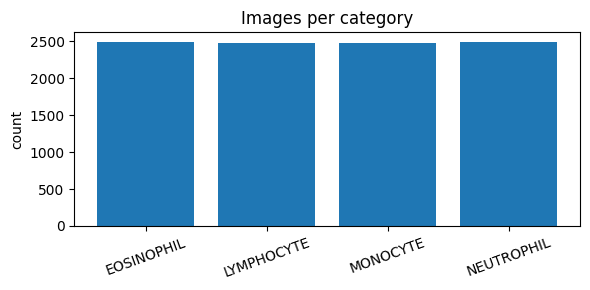

In [5]:
from collections import Counter
counts = Counter()
for cls in class_names:
    counts[cls] = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
for cls, n in counts.items():
    print(f'{cls:12s}: {n} images')

plt.figure(figsize=(6,3))
plt.bar(list(counts.keys()), list(counts.values()))
plt.title('Images per category'); plt.ylabel('count'); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

### Look at real examples
Seeing the images with your own eyes prevents silent labeling mistakes. Note which two categories look most alike — those are the ones the model will most likely confuse (Week 2, Day 2).

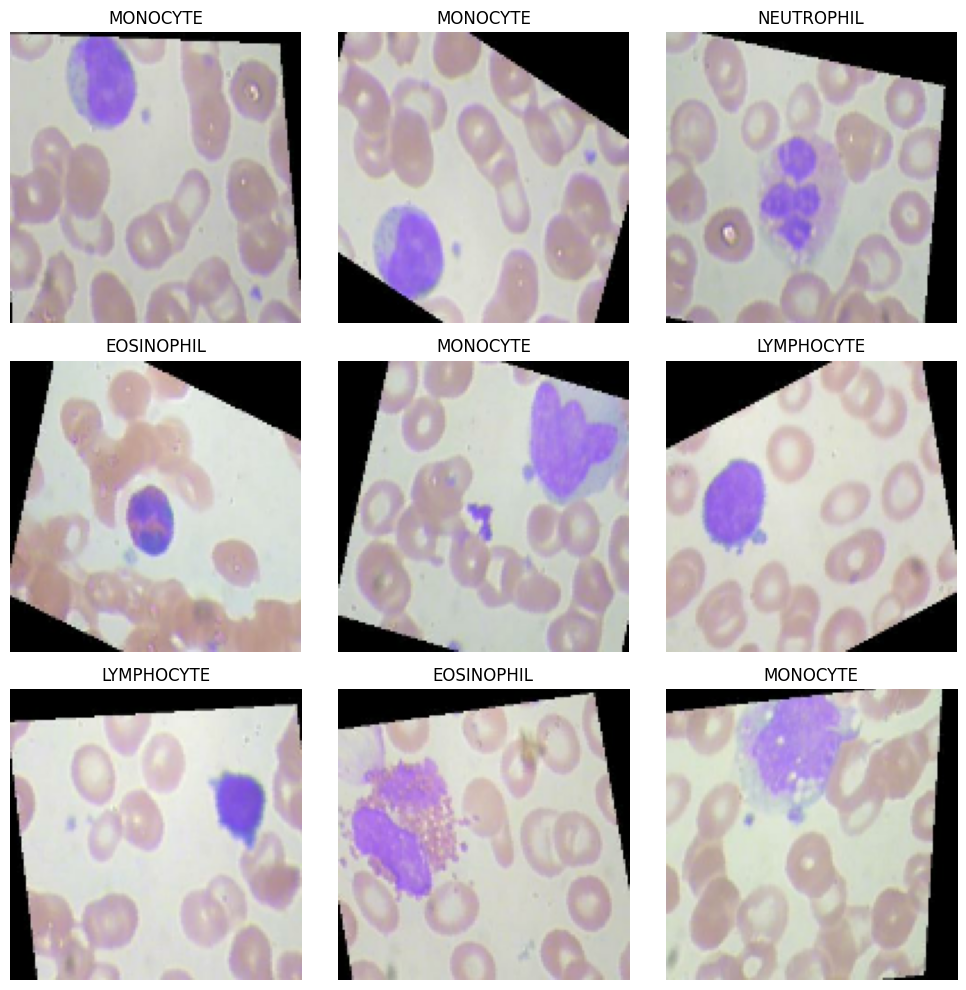

In [6]:
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.tight_layout(); plt.show()

## 4. Prepare — normalize + save the label mapping

Normalizing scales pixel values into the range the pre-trained model expects. We also **save the label mapping** (number → cell-type name) to a file — treat this as a real deliverable, because without it your predictions are just unreadable numbers (Week 2, Day 3).

In [7]:
# Save the number->name mapping so predictions are readable in Week 3/4 and in the app.
label_map = {i: name for i, name in enumerate(class_names)}
with open('label_map.json', 'w') as f:
    json.dump(label_map, f, indent=2)
print('Saved label_map.json:', label_map)

# Performance: cache + prefetch so the GPU is not waiting on disk.
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

Saved label_map.json: {0: 'EOSINOPHIL', 1: 'LYMPHOCYTE', 2: 'MONOCYTE', 3: 'NEUTROPHIL'}


## 5-6. Build & train the model (transfer learning)

We start from **MobileNetV2**, already trained on millions of images, and adapt it to our 4 cell types. Transfer learning gives far better results than training from scratch for a project this size (Week 3, Day 1).

The `data_augmentation` layer (random flips/rotations) is the Week 4 improvement built in from the start — it expands the training set and helps the model generalize. Preprocessing + normalization happen inside the model, so the Streamlit app can feed it a raw image later.

In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name='augment')

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
base_model.trainable = False  # freeze the pre-trained layers first

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)  # scales pixels to [-1,1]
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Train
Start with a short run to confirm the whole pipeline works end to end, then increase `EPOCHS` for a better model. Watch that the loss goes down — if it doesn't, something is wrong (Week 3, Day 1).

In [9]:
EPOCHS = 12  # early stopping may finish sooner
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True)
]
history = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)

Epoch 1/12
249/249 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - accuracy: 0.4799 - loss: 1.2236 - val_accuracy: 0.5269 - val_loss: 1.1306
Epoch 2/12
249/249 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6007 - loss: 0.9589 - val_accuracy: 0.5937 - val_loss: 0.9303
Epoch 3/12
249/249 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.6434 - loss: 0.8715 - val_accuracy: 0.6067 - val_loss: 0.9123
Epoch 4/12
249/249 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.6557 - loss: 0.8368 - val_accuracy: 0.6459 - val_loss: 0.8445
Epoch 5/12
249/249 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6702 - loss: 0.8058 - val_accuracy: 0.6052 - val_loss: 0.9046
Epoch 6/12
249/249 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.6760 - loss: 0.7898 - val_accuracy: 0.6750 - val_loss: 0.7852
Epoch 7/12
249/249 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6843 - loss: 0.7849 - val_accuracy: 0.6123 - val_loss: 0.8852
Epoch 8/12
249/249 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.6864 - loss: 0.7732 - val_acc

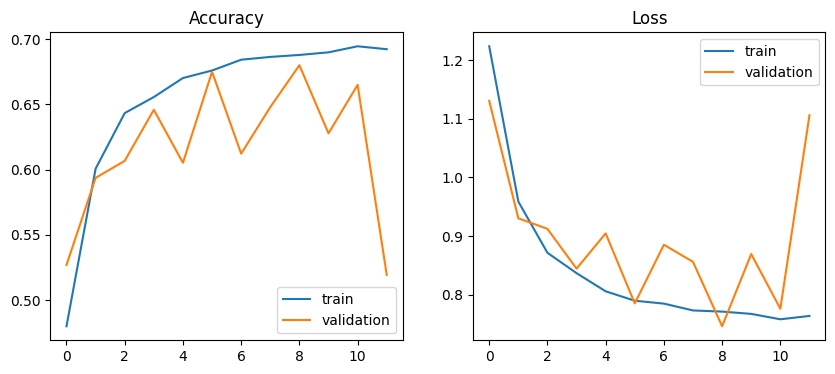

In [10]:
# Plot the learning curves so you can see it actually learned.
acc = history.history['accuracy']; val_acc = history.history['val_accuracy']
loss = history.history['loss']; val_loss = history.history['val_loss']
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(acc,label='train'); plt.plot(val_acc,label='validation'); plt.title('Accuracy'); plt.legend()
plt.subplot(1,2,2); plt.plot(loss,label='train'); plt.plot(val_loss,label='validation'); plt.title('Loss'); plt.legend()
plt.show()

## 7. Evaluate — accuracy + confusion matrix

Now we measure on the held-out test set. **Sanity check:** with 4 equal categories, random guessing is ~25%, so a real model should be well above that. The confusion matrix shows *which* categories the model mixes up — that's where all your improvement ideas come from (Week 3, Days 2-3).

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true, y_pred = [], []
for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(labels.numpy())
y_true = np.array(y_true); y_pred = np.array(y_pred)

accuracy = (y_true == y_pred).mean()
print(f'TEST ACCURACY: {accuracy*100:.1f}%   (random guessing = {100/num_classes:.0f}%)')
print()
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)
with open('test_results.json', 'w') as f:
    json.dump({'test_accuracy': float(accuracy), 'number_of_test_images': len(y_true)}, f, indent=2)
print('Saved test_results.json so the final result is recorded.')

TEST ACCURACY: 45.9%   (random guessing = 25%)

              precision    recall  f1-score   support

  EOSINOPHIL       0.31      0.61      0.41       623
  LYMPHOCYTE       0.69      0.39      0.50       620
    MONOCYTE       0.56      0.35      0.43       620
  NEUTROPHIL       0.60      0.48      0.54       624

    accuracy                           0.46      2487
   macro avg       0.54      0.46      0.47      2487
weighted avg       0.54      0.46      0.47      2487

Saved test_results.json so the final result is recorded.


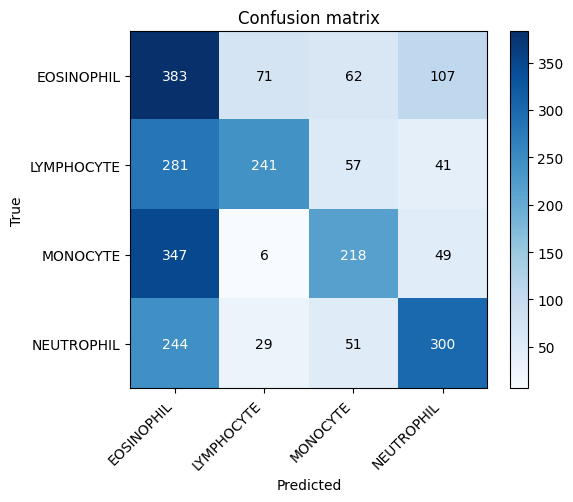

Most-confused pair: TRUE MONOCYTE predicted as EOSINOPHIL (347 times)


In [12]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion matrix'); plt.colorbar()
plt.xticks(range(num_classes), class_names, rotation=45, ha='right')
plt.yticks(range(num_classes), class_names)
plt.xlabel('Predicted'); plt.ylabel('True')
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i,j], ha='center', va='center',
                 color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.tight_layout(); plt.show()

# The two categories the model confuses most (the biggest off-diagonal cell):
cm_off = cm.copy(); np.fill_diagonal(cm_off, 0)
i, j = np.unravel_index(np.argmax(cm_off), cm_off.shape)
print(f'Most-confused pair: TRUE {class_names[i]} predicted as {class_names[j]} ({cm_off[i,j]} times)')

## 8. Study the failures
Look at images the model got wrong. Are they blurry, rare, or genuinely ambiguous? Write down the patterns — this is the evidence behind your improvement hypothesis (Week 3, Day 4).

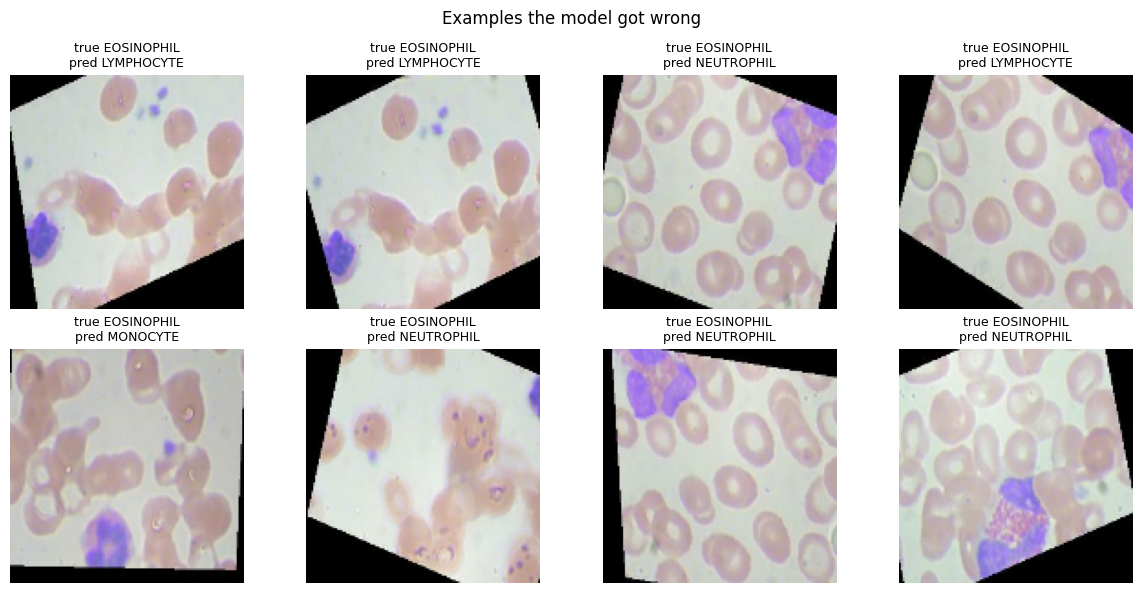

In [13]:
shown = 0
plt.figure(figsize=(12,6))
for images, labels in test_ds.take(4):
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    for k in range(len(images)):
        if preds[k] != labels[k].numpy() and shown < 8:
            ax = plt.subplot(2,4,shown+1)
            plt.imshow(images[k].numpy().astype('uint8'))
            plt.title(f'true {class_names[labels[k]]}\npred {class_names[preds[k]]}', fontsize=9)
            plt.axis('off')
            shown += 1
plt.suptitle('Examples the model got wrong'); plt.tight_layout(); plt.show()

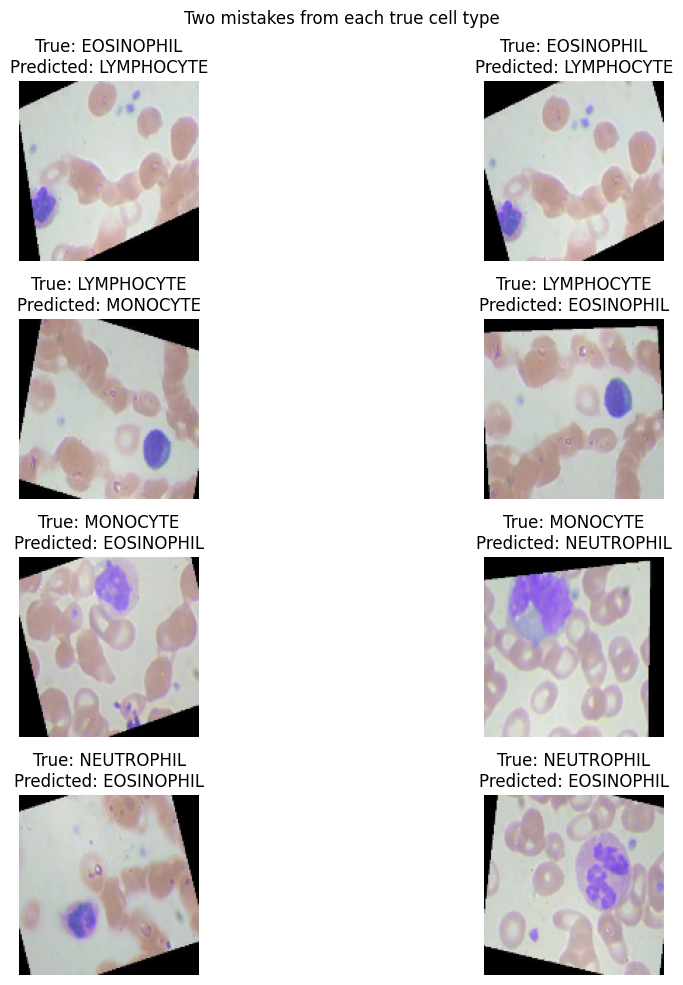

In [14]:
# Show two incorrect predictions from every true cell type
mistakes = {name: [] for name in class_names}

for images, labels in test_ds:
    probabilities = model.predict(images, verbose=0)
    predictions = np.argmax(probabilities, axis=1)

    for image, true_label, predicted_label in zip(
        images, labels.numpy(), predictions
    ):
        true_name = class_names[true_label]

        if (
            true_label != predicted_label
            and len(mistakes[true_name]) < 2
        ):
            mistakes[true_name].append(
                (image.numpy().astype("uint8"), predicted_label)
            )

    if all(len(examples) >= 2 for examples in mistakes.values()):
        break

plt.figure(figsize=(12, 10))
plot_number = 1

for true_name, examples in mistakes.items():
    for image, predicted_label in examples:
        ax = plt.subplot(4, 2, plot_number)
        plt.imshow(image)
        plt.title(
            f"True: {true_name}\n"
            f"Predicted: {class_names[predicted_label]}"
        )
        plt.axis("off")
        plot_number += 1

plt.suptitle("Two mistakes from each true cell type")
plt.tight_layout()
plt.show()

## Week 3 findings and improvement hypothesis

The first model achieved 45.9% test accuracy, compared with 25% for
random guessing. Its most common error was classifying monocytes as
eosinophils, which happened 347 times.

The failure examples show that some cells are small, partly cut off, or
surrounded by black borders. The model also predicts eosinophil too often.

I hypothesize that carefully fine-tuning the final layers of MobileNetV2
with a low learning rate will improve accuracy. The pretrained layers
currently remain completely frozen, so they have not adapted their
higher-level visual features specifically to blood-cell images.

## 9. Save the model + label map (for the Streamlit app)

This exports everything the Week 4 interface needs. Download both files from the Colab file panel, or save them to your shared Drive folder.

In [15]:
model.save('blood_cell_model.keras')
print('Saved blood_cell_model.keras and label_map.json')

# Optional: copy to your shared Google Drive folder so the team has them.
# from google.colab import drive
# drive.mount('/content/drive')
# !cp blood_cell_model.keras label_map.json '/content/drive/MyDrive/YOUR_TEAM_FOLDER/'

Saved blood_cell_model.keras and label_map.json


In [16]:
model.save("blood_cell_model_week3.keras")
print("Saved the Week 3 baseline model with 45.9% test accuracy.")

Saved the Week 3 baseline model with 45.9% test accuracy.


In [17]:
# Week 4 improvement: prepare the model for fine-tuning

baseline_accuracy = float(accuracy)

base_model.trainable = True

# Only allow the final 20 MobileNetV2 layers to change
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Keep these special normalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

trainable_parameters = sum(
    np.prod(variable.shape) for variable in model.trainable_weights
)

print(f"Baseline test accuracy: {baseline_accuracy * 100:.1f}%")
print(f"Trainable parameters: {trainable_parameters:,}")

Baseline test accuracy: 45.9%
Trainable parameters: 1,200,004


## Week 4 improvement — Fine-tuning MobileNetV2

### Why I chose this improvement

The Week 3 baseline model achieved **45.9% test accuracy**. Its most
common mistake was predicting a **monocyte as an eosinophil**, which
happened 347 times. The validation graph also showed signs of
overfitting.

During the baseline training, all of MobileNetV2's pretrained layers
were frozen. Only the final four-class prediction layer could learn.

For my Week 4 improvement, I will unfreeze the final 20 MobileNetV2
layers and train them using a very small learning rate. This is called
fine-tuning. It allows the model to adapt some of its general visual
knowledge to blood-cell shapes and textures without completely
overwriting what it previously learned.

### Hypothesis

I predict that fine-tuning the final layers will improve test accuracy
above the 45.9% baseline and reduce the number of monocytes incorrectly
classified as eosinophils.

---
### What you now have (deliverables)
- A clean train/test split with a fixed seed (honest measurement)
- A trained model with a real **test accuracy** number
- A **confusion matrix** showing which cell types get confused
- Example failures to study
- A saved model + label map for the interface

### Your improvement hypothesis (fill in for Week 3 → Week 4)
> The model most confuses **MONOCYTE** with **EOSINOPHIL**. I think
> **unfreezing the final 20 layers of MobileNetV2 and fine-tuning them**
> will help most, because **the pretrained layers can adapt their general
> visual features to blood-cell shapes and textures**. I expect accuracy
> to go from **45.9%** to about **55%**.

Change `EPOCHS`, or unfreeze the top of `base_model` for fine-tuning, re-run, and record before/after.

In [18]:
fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )
]

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,
    callbacks=fine_tune_callbacks
)

Epoch 1/6
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.7175 - loss: 0.7029 - val_accuracy: 0.6379 - val_loss: 0.8508
Epoch 2/6
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.7589 - loss: 0.6147 - val_accuracy: 0.6484 - val_loss: 0.8119
Epoch 3/6
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.7819 - loss: 0.5440 - val_accuracy: 0.7413 - val_loss: 0.5968
Epoch 4/6
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.8058 - loss: 0.4897 - val_accuracy: 0.7398 - val_loss: 0.6111
Epoch 5/6
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.8157 - loss: 0.4593 - val_accuracy: 0.7730 - val_loss: 0.5588
Epoch 6/6
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.8369 - loss: 0.4152 - val_accuracy: 0.7554 - val_loss: 0.5982


### Measuring whether fine-tuning helped

The fine-tuning stage reached its best validation accuracy at approximately
**77.3%**. However, validation accuracy is not the final result because the
validation images influenced decisions made during training.

I will now evaluate the fine-tuned model on the untouched test set of
2,487 images. I will compare this result with the Week 3 baseline accuracy
of **45.9%**. Using the same test set makes the before-and-after comparison
fair.

I will consider fine-tuning successful if it increases test accuracy. I
will also examine the per-class results and confusion matrix to determine
whether it reduced the model's tendency to confuse monocytes with
eosinophils.

In [19]:
# Evaluate the fine-tuned model on the untouched test set

improved_probabilities = model.predict(test_ds, verbose=1)
improved_predictions = np.argmax(improved_probabilities, axis=1)

improved_accuracy = (
    y_true == improved_predictions
).mean()

print(f"Week 3 baseline accuracy: {baseline_accuracy * 100:.1f}%")
print(f"Week 4 improved accuracy: {improved_accuracy * 100:.1f}%")
print(
    f"Accuracy change: "
    f"{(improved_accuracy - baseline_accuracy) * 100:+.1f} percentage points"
)

print()
print(
    classification_report(
        y_true,
        improved_predictions,
        target_names=class_names
    )
)

78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step
Week 3 baseline accuracy: 45.9%
Week 4 improved accuracy: 46.2%
Accuracy change: +0.2 percentage points

              precision    recall  f1-score   support

  EOSINOPHIL       0.29      0.69      0.41       623
  LYMPHOCYTE       0.76      0.35      0.48       620
    MONOCYTE       0.69      0.36      0.48       620
  NEUTROPHIL       0.66      0.45      0.53       624

    accuracy                           0.46      2487
   macro avg       0.60      0.46      0.48      2487
weighted avg       0.60      0.46      0.48      2487



### Initial fine-tuning result

Fine-tuning increased test accuracy from **45.9% to 46.2%**, an improvement
of approximately **0.2 percentage points**. This is a measurable but small
improvement.

The hypothesis was only weakly supported. Fine-tuning improved precision
for some classes, particularly lymphocytes and monocytes, but it did not
produce a large improvement in overall accuracy. I will use the confusion
matrix to check whether the most common error—monocytes being predicted as
eosinophils—was reduced.

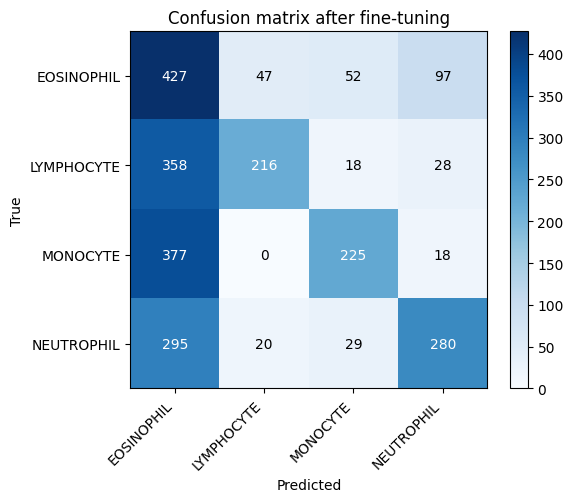

Before fine-tuning: 347 monocytes predicted as eosinophils
After fine-tuning: 377 monocytes predicted as eosinophils


In [20]:
# Confusion matrix after fine-tuning

improved_cm = confusion_matrix(y_true, improved_predictions)

plt.figure(figsize=(6, 5))
plt.imshow(improved_cm, cmap="Blues")
plt.title("Confusion matrix after fine-tuning")
plt.colorbar()

plt.xticks(
    range(num_classes),
    class_names,
    rotation=45,
    ha="right"
)
plt.yticks(range(num_classes), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(
            j,
            i,
            improved_cm[i, j],
            ha="center",
            va="center",
            color=(
                "white"
                if improved_cm[i, j] > improved_cm.max() / 2
                else "black"
            )
        )

plt.tight_layout()
plt.show()

monocyte_index = class_names.index("MONOCYTE")
eosinophil_index = class_names.index("EOSINOPHIL")
new_monocyte_eosinophil_errors = improved_cm[
    monocyte_index, eosinophil_index
]

print("Before fine-tuning: 347 monocytes predicted as eosinophils")
print(
    "After fine-tuning:",
    new_monocyte_eosinophil_errors,
    "monocytes predicted as eosinophils"
)

### Fine-tuning conclusion

Fine-tuning produced only a small overall increase from **45.9% to
46.2%**. More importantly, monocyte-to-eosinophil errors increased from
**347 to 377**. Therefore, this change did not solve the model's main
problem, and I rejected the fine-tuned model as the final version.

The failure examples suggest that important cell details may be lost when
the original images are resized to 128 × 128 pixels. My next experiment
will use 224 × 224 images so the model can see more detail in the nucleus
shape and cell texture.

### Second improvement experiment — Higher image resolution

The original model resized every image to **128 × 128 pixels**. The failure
examples showed cells that were small, partly cut off, or difficult to
distinguish. Reducing the images to 128 × 128 may remove useful details
from the nucleus shape and cell texture.

For this experiment, I created new training, validation, and test datasets
at **224 × 224 pixels**. I kept the same random seed and the same dataset
split so the comparison remains fair.

I will build a fresh MobileNetV2 model instead of continuing from the
fine-tuned model. This ensures that the main experimental change is the
image resolution rather than previously modified weights.

#### Hypothesis

Preserving more visual detail at 224 × 224 will improve test accuracy
above the 45.9% Week 3 baseline and may help the model distinguish
monocytes from eosinophils.

### Second improvement hypothesis — Higher image resolution

> The model still most confuses **MONOCYTE** with **EOSINOPHIL**. I think
> **increasing the image resolution from 128 × 128 to 224 × 224** will
> help most, because **higher-resolution images preserve more information
> about nucleus shape, cell texture, and other small visual differences
> between blood-cell types**. I expect accuracy to improve from **45.9%**
> to about **55%**.

In [21]:
# Create 224 x 224 datasets for the second improvement experiment

HIGH_RES_SIZE = (224, 224)

train_224 = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=HIGH_RES_SIZE,
    batch_size=BATCH_SIZE
)

val_224 = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=HIGH_RES_SIZE,
    batch_size=BATCH_SIZE
)

test_224 = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    shuffle=False,
    image_size=HIGH_RES_SIZE,
    batch_size=BATCH_SIZE
)

# Load upcoming batches while the GPU processes the current batch
train_224 = train_224.prefetch(tf.data.AUTOTUNE)
val_224 = val_224.prefetch(tf.data.AUTOTUNE)
test_224 = test_224.prefetch(tf.data.AUTOTUNE)

print("Created 224 x 224 training, validation, and test datasets.")

Found 9957 files belonging to 4 classes.
Using 7966 files for training.
Found 9957 files belonging to 4 classes.
Using 1991 files for validation.
Found 2487 files belonging to 4 classes.
Created 224 x 224 training, validation, and test datasets.


In [22]:
# Build a fresh MobileNetV2 model for 224 x 224 images

augmentation_224 = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="augmentation_224")

base_model_224 = tf.keras.applications.MobileNetV2(
    input_shape=HIGH_RES_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

# Freeze the pretrained portion during initial training
base_model_224.trainable = False

inputs_224 = tf.keras.Input(shape=HIGH_RES_SIZE + (3,))
x = augmentation_224(inputs_224)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model_224(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)

outputs_224 = tf.keras.layers.Dense(
    num_classes,
    activation="softmax"
)(x)

model_224 = tf.keras.Model(inputs_224, outputs_224)

model_224.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Created the fresh 224 x 224 MobileNetV2 model.")
print(
    "Trainable parameters:",
    sum(np.prod(v.shape) for v in model_224.trainable_weights)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Created the fresh 224 x 224 MobileNetV2 model.
Trainable parameters: 5124


### Training the 224 × 224 model

I will first train only the new four-class prediction layer while keeping
MobileNetV2's pretrained layers frozen. This matches the initial training
method used for the 128 × 128 baseline and helps isolate image resolution
as the main experimental change.

The model may train for up to 12 epochs. Early stopping will stop training
if validation loss does not improve for three consecutive epochs. It will
then restore the weights from the epoch with the lowest validation loss.
This reduces overfitting and ensures that the final evaluation uses the
best version observed during training.

In [23]:
high_res_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]

high_res_history = model_224.fit(
    train_224,
    validation_data=val_224,
    epochs=12,
    callbacks=high_res_callbacks
)

Epoch 1/12
249/249 ━━━━━━━━━━━━━━━━━━━━ 27s 85ms/step - accuracy: 0.4630 - loss: 1.2404 - val_accuracy: 0.6349 - val_loss: 0.9157
Epoch 2/12
249/249 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - accuracy: 0.6156 - loss: 0.9255 - val_accuracy: 0.6931 - val_loss: 0.7817
Epoch 3/12
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/step - accuracy: 0.6589 - loss: 0.8370 - val_accuracy: 0.7022 - val_loss: 0.7497
Epoch 4/12
249/249 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.6805 - loss: 0.7940 - val_accuracy: 0.7072 - val_loss: 0.7178
Epoch 5/12
249/249 ━━━━━━━━━━━━━━━━━━━━ 22s 79ms/step - accuracy: 0.6932 - loss: 0.7589 - val_accuracy: 0.7459 - val_loss: 0.6578
Epoch 6/12
249/249 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - accuracy: 0.6898 - loss: 0.7587 - val_accuracy: 0.7368 - val_loss: 0.6634
Epoch 7/12
249/249 ━━━━━━━━━━━━━━━━━━━━ 22s 80ms/step - accuracy: 0.7084 - loss: 0.7246 - val_accuracy: 0.7519 - val_loss: 0.6361
Epoch 8/12
249/249 ━━━━━━━━━━━━━━━━━━━━ 19s 74ms/step - accuracy: 0.7108 - loss: 0.7111 - 

### Evaluating the higher-resolution model

The 224 × 224 model reached a best validation accuracy of approximately
**78.0%**. I will now evaluate it on the same untouched set of 2,487 test
images used for the Week 3 baseline.

The final test result will be compared with:

- **45.9%** for the original 128 × 128 baseline
- **46.2%** after fine-tuning the 128 × 128 model

The higher-resolution experiment will only be considered successful if it
improves performance on the separate test set, not merely on validation
images.

In [24]:
# Evaluate the 224 x 224 model on the untouched test set

high_res_probabilities = model_224.predict(
    test_224,
    verbose=1
)
high_res_predictions = np.argmax(
    high_res_probabilities,
    axis=1
)

high_res_true_labels = np.concatenate([
    labels.numpy() for images, labels in test_224
])

high_res_accuracy = (
    high_res_true_labels == high_res_predictions
).mean()

print(f"Original baseline: {baseline_accuracy * 100:.1f}%")
print(f"Fine-tuned 128 x 128 model: {improved_accuracy * 100:.1f}%")
print(f"New 224 x 224 model: {high_res_accuracy * 100:.1f}%")
print(
    "Change from original baseline:",
    f"{(high_res_accuracy - baseline_accuracy) * 100:+.1f}",
    "percentage points"
)

print()
print(
    classification_report(
        high_res_true_labels,
        high_res_predictions,
        target_names=class_names
    )
)

78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step
Original baseline: 45.9%
Fine-tuned 128 x 128 model: 46.2%
New 224 x 224 model: 57.4%
Change from original baseline: +11.5 percentage points

              precision    recall  f1-score   support

  EOSINOPHIL       0.42      0.61      0.50       623
  LYMPHOCYTE       0.77      0.53      0.63       620
    MONOCYTE       0.73      0.54      0.62       620
  NEUTROPHIL       0.55      0.61      0.58       624

    accuracy                           0.57      2487
   macro avg       0.62      0.57      0.58      2487
weighted avg       0.62      0.57      0.58      2487



### Higher-resolution result

The 224 × 224 model achieved **57.4% test accuracy**, compared with
**45.9%** for the original baseline. This is an improvement of
**11.5 percentage points**.

This result supports my hypothesis that the 128 × 128 images discarded
useful visual details. Higher-resolution images helped the model examine
nucleus shapes and cell textures more effectively.

The improvement was especially visible in the lymphocyte and monocyte
results. However, 57.4% accuracy is not sufficient for medical use. This
remains an educational prototype that requires human review and must not
be used for diagnosis.

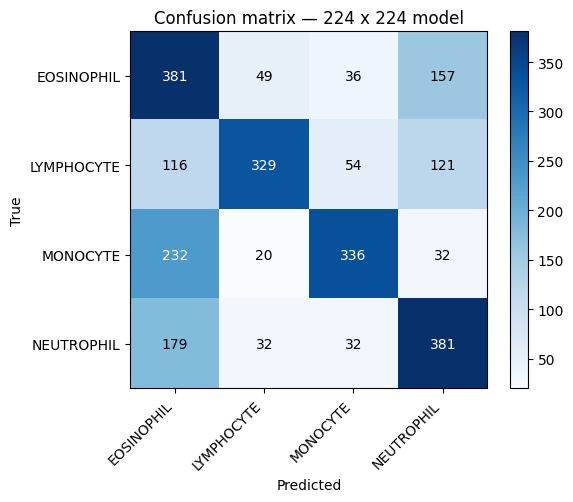

Most-confused pair: TRUE MONOCYTE predicted as EOSINOPHIL (232 times)
Monocyte -> eosinophil errors: 232


In [25]:
# Confusion matrix for the selected 224 x 224 model

high_res_cm = confusion_matrix(
    high_res_true_labels,
    high_res_predictions
)

plt.figure(figsize=(6, 5))
plt.imshow(high_res_cm, cmap="Blues")
plt.title("Confusion matrix — 224 x 224 model")
plt.colorbar()

plt.xticks(
    range(num_classes),
    class_names,
    rotation=45,
    ha="right"
)
plt.yticks(range(num_classes), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(
            j,
            i,
            high_res_cm[i, j],
            ha="center",
            va="center",
            color=(
                "white"
                if high_res_cm[i, j] > high_res_cm.max() / 2
                else "black"
            )
        )

plt.tight_layout()
plt.show()

# Identify the largest off-diagonal error
off_diagonal = high_res_cm.copy()
np.fill_diagonal(off_diagonal, 0)

true_index, predicted_index = np.unravel_index(
    np.argmax(off_diagonal),
    off_diagonal.shape
)

print(
    "Most-confused pair:",
    f"TRUE {class_names[true_index]}",
    f"predicted as {class_names[predicted_index]}",
    f"({off_diagonal[true_index, predicted_index]} times)"
)

print(
    "Monocyte -> eosinophil errors:",
    high_res_cm[
        class_names.index("MONOCYTE"),
        class_names.index("EOSINOPHIL")
    ]
)

### Selecting the final Week 4 model

I selected the 224 × 224 model as the final Week 4 version because it
increased test accuracy from **45.9% to 57.4%** and reduced the main
monocyte-to-eosinophil error from **347 to 232 cases**.

I did not continue increasing resolution because larger inputs do not
guarantee better accuracy, require more computation, and could cause the
project to become tuned too closely to the test set. Testing another
resolution can be considered future work.

In [26]:
# Save the selected Week 4 model and its results

# Descriptive copy
model_224.save("blood_cell_model_224.keras")

# This standard filename is used by the Streamlit interface
model_224.save("blood_cell_model.keras")

final_results = {
    "week3_baseline_accuracy": float(baseline_accuracy),
    "fine_tuned_128_accuracy": float(improved_accuracy),
    "final_224_accuracy": float(high_res_accuracy),
    "accuracy_improvement_percentage_points": float(
        (high_res_accuracy - baseline_accuracy) * 100
    ),
    "most_confused_true_class": class_names[true_index],
    "most_confused_predicted_class": class_names[predicted_index],
    "most_confused_count": int(
        off_diagonal[true_index, predicted_index]
    ),
    "confusion_matrix": high_res_cm.tolist(),
    "image_size": [224, 224],
    "number_of_test_images": int(len(high_res_true_labels))
}

with open("final_results.json", "w") as file:
    json.dump(final_results, file, indent=2)

print("Saved the selected 224 x 224 model.")
print("Saved final_results.json.")

Saved the selected 224 x 224 model.
Saved final_results.json.


### Higher-resolution improvement summary

The higher-resolution model achieved **57.4% test accuracy**, exceeding
the predicted accuracy of about **55%**. This improved upon the original
45.9% baseline by **11.5 percentage points**.

The number of monocytes incorrectly classified as eosinophils decreased
from **347 to 232**, while correct monocyte predictions increased from
**218 to 336**. Correct predictions also increased for lymphocytes and
neutrophils.

These results support the hypothesis that 224 × 224 images preserve useful
details about nucleus shape and cell texture. The 224 × 224 model was
therefore selected as the final Week 4 model. It remains an educational
prototype and is not suitable for medical diagnosis.

### Selecting a human-review confidence threshold

The interface should not automatically trust every prediction. I will
compare several confidence thresholds using the final model's test
predictions.

A prediction below the selected threshold will be flagged for human
review. A higher threshold may make accepted predictions more reliable,
but it will also send more images to a human. This experiment will help
choose a reasonable balance rather than using an arbitrary cutoff.

In [27]:
# Compare possible human-review confidence thresholds

final_confidences = np.max(
    high_res_probabilities,
    axis=1
)

final_correct = (
    high_res_predictions == high_res_true_labels
)

print(
    f"{'Threshold':<12}"
    f"{'Flagged':<12}"
    f"{'Accepted':<12}"
    f"{'Accepted accuracy'}"
)

for threshold in [0.40, 0.50, 0.60, 0.70, 0.80, 0.90]:
    accepted = final_confidences >= threshold
    flagged_count = np.sum(~accepted)
    accepted_count = np.sum(accepted)

    if accepted_count > 0:
        accepted_accuracy = np.mean(
            final_correct[accepted]
        )
    else:
        accepted_accuracy = 0

    print(
        f"{threshold:<12.2f}"
        f"{flagged_count:<12}"
        f"{accepted_count:<12}"
        f"{accepted_accuracy * 100:.1f}%"
    )

Threshold   Flagged     Accepted    Accepted accuracy
0.40        162         2325        59.2%
0.50        599         1888        64.4%
0.60        1089        1398        68.4%
0.70        1520        967         72.3%
0.80        1877        610         73.8%
0.90        2186        301         79.1%


### Selected confidence threshold

I selected a confidence threshold of **50%**. Predictions below 50% will
be flagged for human review.

At this threshold, the model:

- Flags **599 of 2,487 test images**, or about **24%**
- Accepts **1,888 test images**, or about **76%**
- Achieves **64.4% accuracy on accepted predictions**

I chose 50% instead of 60% because increasing the threshold to 60% only
improved accepted accuracy by four percentage points, but required an
additional 490 images to be reviewed by a human. The 50% threshold
provides a more practical balance between prediction accuracy and human
review workload.

Confidence does not guarantee correctness. This remains an educational
prototype and is not suitable for medical diagnosis.

In [28]:
# Add the selected confidence threshold to the saved results

selected_threshold = 0.50
accepted = final_confidences >= selected_threshold

final_results["confidence_threshold"] = selected_threshold
final_results["flagged_for_review"] = int(np.sum(~accepted))
final_results["accepted_predictions"] = int(np.sum(accepted))
final_results["accepted_accuracy"] = float(
    np.mean(final_correct[accepted])
)

with open("final_results.json", "w") as file:
    json.dump(final_results, file, indent=2)

print("Saved 50% confidence threshold to final_results.json.")

Saved 50% confidence threshold to final_results.json.
